In [17]:
import pandas as pd
import numpy as np

PREDICTION_FILE = "../data/recent_predictions.parquet"

df = pd.read_parquet( PREDICTION_FILE )

print( f"Rows: {len(df):,}" )
print( f"Tickers: {df['ticker'].nunique():,}" )

df.head()

Rows: 4,848
Tickers: 4,848


,ticker,date,price,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y,future_ret_1y,linear_regression_score,random_forest_score,gradient_boosting_score,neural_network_score,linear_regression_score_rank,random_forest_score_rank,gradient_boosting_score_rank,neural_network_score_rank,combined_score
3991,BINI,2025-07-01,77.500000,-0.279070,-0.693069,-0.961250,-1.000000,-1.000000,-1.000000,-1.000000,-0.999097,0.059792,4.888366,0.994966,1.180530,0.993812,0.996493,0.987314,0.994637,0.993064
3279,HSDT,2025-07-01,8.595000,-0.055495,-0.472699,-0.958022,-0.985852,-0.988306,-0.999799,-0.999985,-0.797557,0.047499,4.888366,1.063430,1.028742,0.992368,0.996493,0.988861,0.993193,0.992729
3968,GNLN,2025-07-01,35.119999,-0.171698,-0.349630,-0.024444,-0.996387,-0.998435,-0.999986,-0.999999,-0.933087,0.000422,4.888366,1.291496,1.556574,0.974010,0.996493,0.992574,0.995462,0.989635
3950,OGEN,2025-07-01,1.550000,-0.594241,-0.570637,-0.569444,-0.867521,-0.950321,-0.997608,-0.998852,-0.606452,0.044167,4.888366,0.994966,0.433775,0.991955,0.996493,0.987314,0.976898,0.988165
1661,SRPT,2025-07-01,17.709999,0.035672,-0.066913,-0.528989,-0.856448,-0.887911,-0.770209,-0.891183,0.027668,0.007533,4.715011,2.517998,0.460756,0.979785,0.990924,0.998556,0.979373,0.987160


In [18]:
score_cols = [
    col for col in df.columns
    if col.endswith("_score")
]

rank_cols = [
    col for col in df.columns
    if col.endswith("_score_rank")
]

print("Prediction columns:")
for c in score_cols:
    print(" ", c)

print("\nRank columns:")
for c in rank_cols:
    print(" ", c)

Prediction columns:
  linear_regression_score
  random_forest_score
  gradient_boosting_score
  neural_network_score
  combined_score

Rank columns:
  linear_regression_score_rank
  random_forest_score_rank
  gradient_boosting_score_rank
  neural_network_score_rank


In [19]:
stats = df[score_cols].describe().T

stats["median"] = df[score_cols].median()
stats["std"] = df[score_cols].std()

stats

,count,mean,std,min,25%,50%,75%,max,median
linear_regression_score,4848.0,-6100.371133,4.350305e+05,-3.028173e+07,-0.050358,-0.042327,-0.034410,706731.351482,-0.042327
random_forest_score,4848.0,0.029401,5.009706e-01,-3.835042e-01,-0.067426,-0.048758,-0.002126,4.888366,-0.048758
gradient_boosting_score,4848.0,-0.006662,2.443998e-01,-9.392415e-01,-0.078428,-0.045554,-0.006473,5.104957,-0.045554
neural_network_score,4848.0,-87660.250151,6.096489e+06,-4.244836e+08,-0.087597,-0.049979,-0.007483,20810.494799,-0.049979
combined_score,4848.0,0.500103,2.254988e-01,4.125413e-03,0.321930,0.486064,0.667885,0.993064,0.486064


In [20]:
for col in score_cols:
    print("="*60)
    print(col)
    
    display(
        df.sort_values(
            col,
            ascending=False
        )
        [
            [
                "ticker",
                "date",
                col
            ]
        ]
        .head(20)
    )

linear_regression_score


,ticker,date,linear_regression_score
4224,MNBEF,2025-07-01,706731.351482
4314,RYKKF,2025-07-01,1877.750437
4761,SATLF,2025-07-01,91.329693
4223,GPAEF,2025-07-01,8.417205
4758,PSKRF,2025-07-01,7.620903
4769,LSRCF,2025-07-01,7.600620
3960,PPCB,2025-07-01,3.620424
976,CHRD,2025-07-01,2.094267
3394,EUBG,2025-07-01,2.065591
3600,CHEV,2025-07-01,1.289715


random_forest_score


,ticker,date,random_forest_score
3962,AGMH,2025-07-01,4.888366
3912,JAGX,2025-07-01,4.888366
3974,XXII,2025-07-01,4.888366
3768,RIME,2025-07-01,4.888366
2659,XFOR,2025-07-01,4.888366
3669,NAAS,2025-07-01,4.888366
3767,HIND,2025-07-01,4.888366
3670,QCLS,2025-07-01,4.888366
3279,HSDT,2025-07-01,4.888366
3881,MNTS,2025-07-01,4.888366


gradient_boosting_score


,ticker,date,gradient_boosting_score
2739,BNED,2025-07-01,5.104957
3949,CASIF,2025-07-01,4.496678
3918,PRSI,2025-07-01,2.868042
3792,GTBP,2025-07-01,2.816419
3378,HAIN,2025-07-01,2.809765
3068,CRBP,2025-07-01,2.769479
3617,CRVO,2025-07-01,2.554627
1661,SRPT,2025-07-01,2.517998
3653,TPST,2025-07-01,2.217247
3897,VS,2025-07-01,2.209783


neural_network_score


,ticker,date,neural_network_score
4750,IBIDF,2025-07-01,20810.494799
4290,DISPF,2025-07-01,617.224406
4792,NOFCF,2025-07-01,43.126882
4234,DINRF,2025-07-01,23.593604
4782,NHKGF,2025-07-01,8.829536
4781,NGSCF,2025-07-01,7.575353
2692,TSSI,2025-07-01,7.292910
4826,YMTKF,2025-07-01,6.488551
4631,SBBTF,2025-07-01,6.319861
4777,HACBF,2025-07-01,5.966530


combined_score


,ticker,date,combined_score
3991,BINI,2025-07-01,0.993064
3279,HSDT,2025-07-01,0.992729
3968,GNLN,2025-07-01,0.989635
3950,OGEN,2025-07-01,0.988165
1661,SRPT,2025-07-01,0.987160
3881,MNTS,2025-07-01,0.987057
3691,LFWD,2025-07-01,0.986231
3670,QCLS,2025-07-01,0.985767
3767,HIND,2025-07-01,0.985613
2659,XFOR,2025-07-01,0.985200


In [21]:
df.sort_values(
    "combined_score",
    ascending=False
)[
    [
        "ticker",
        "date",
        "combined_score"
    ]
].head(20)

,ticker,date,combined_score
3991,BINI,2025-07-01,0.993064
3279,HSDT,2025-07-01,0.992729
3968,GNLN,2025-07-01,0.989635
3950,OGEN,2025-07-01,0.988165
1661,SRPT,2025-07-01,0.987160
3881,MNTS,2025-07-01,0.987057
3691,LFWD,2025-07-01,0.986231
3670,QCLS,2025-07-01,0.985767
3767,HIND,2025-07-01,0.985613
2659,XFOR,2025-07-01,0.985200


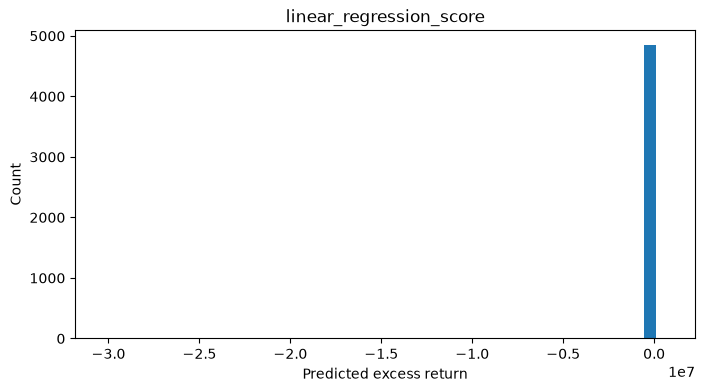

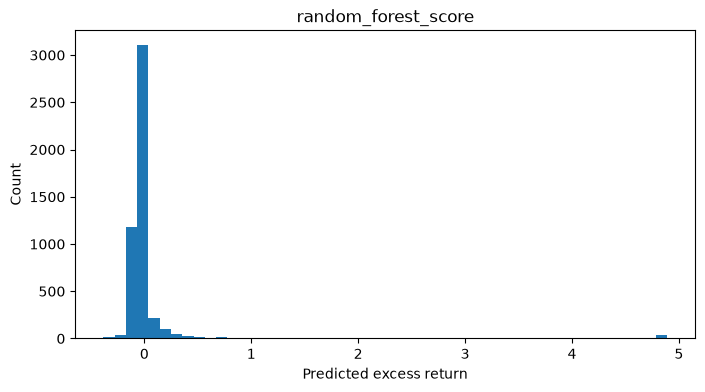

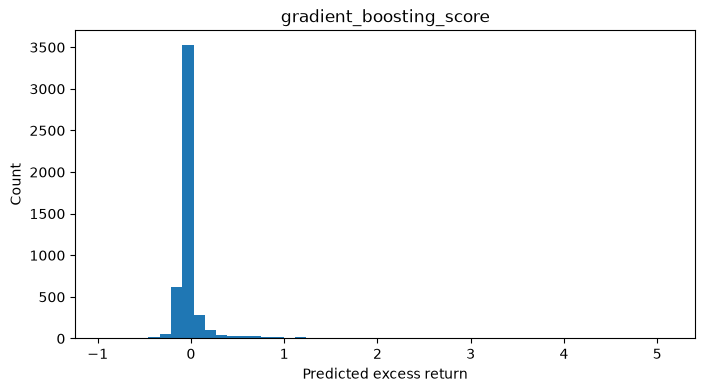

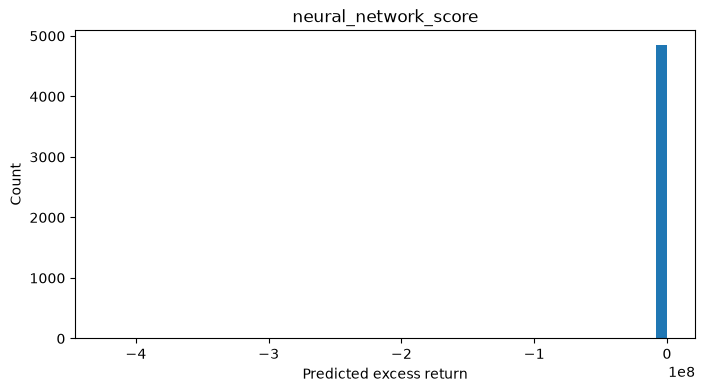

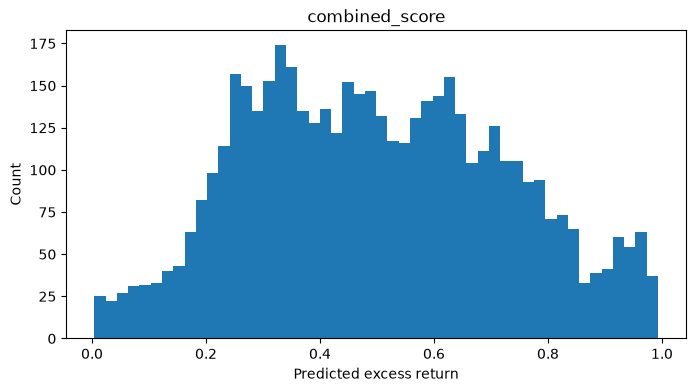

In [22]:
import matplotlib.pyplot as plt

for col in score_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=50)
    plt.title(col)
    plt.xlabel("Predicted excess return")
    plt.ylabel("Count")
    plt.show()

In [23]:
df.columns.to_list()

['ticker',
 'date',
 'price',
 'ret_1d',
 'ret_1w',
 'ret_1m',
 'ret_6m',
 'ret_1y',
 'ret_3y',
 'ret_5y',
 'future_ret_1y',
 'linear_regression_score',
 'random_forest_score',
 'gradient_boosting_score',
 'neural_network_score',
 'linear_regression_score_rank',
 'random_forest_score_rank',
 'gradient_boosting_score_rank',
 'neural_network_score_rank',
 'combined_score']

In [28]:
TOP_PERCENT = 0.20  # top 10%

score_cols = [
    col for col in df.columns
    if col.endswith("_score")
]

results = []

for model in score_cols:
    ranked = df.sort_values(
        model,
        ascending=False
    )

    n = max(1, int(len(ranked) * TOP_PERCENT))

    top = ranked.head(n)

    results.append({
        "model": model,
        "stocks": n,
        "mean_return": top["future_ret_1y"].mean(),
        "median_return": top["future_ret_1y"].median(),
    })

results_df = pd.DataFrame(results)

results_df

,model,stocks,mean_return,median_return
0,linear_regression_score,969,0.232241,-0.004167
1,random_forest_score,969,0.341675,-0.005882
2,gradient_boosting_score,969,0.344492,-0.014493
3,neural_network_score,969,0.325920,-0.056884
4,combined_score,969,0.333235,0.003862
